# S6 — Bonus: hands-on with a public dataset (GSE106118)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S6_Bonus_GSE106118.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

Everything so far used data we prepared for you. This notebook takes a dataset
straight from a public repository and walks the whole way from raw file to
biological result.

**GSE106118** is a *single-cell* RNA-seq dataset from human embryonic heart
(Cui et al., *Cell Reports* 2019). The file we use here, `HE10W`, holds 193
individual cells from a 10-week embryo, each belonging to one of the four
chambers: left atrium (LA), right atrium (RA), left ventricle (LV), right
ventricle (RV). We ask which genes distinguish the chambers.

> **Why a single-cell dataset in a bulk course?** Because the file looks exactly
> like a bulk matrix — genes down the rows, one column per column — and telling
> the difference is a skill worth having. Two consequences run through the whole
> notebook: the matrix is **sparse** (most entries are zero, which is a property
> of the technology, not of the biology), and the columns are **cells, not
> biological replicates**. Section 5 aggregates cells into *pseudo-bulk* profiles
> before making any chamber-level statement, and section 8 is explicit about how
> far the statistics actually reach.

You will practise: parsing a real file, deriving metadata from column names, QC,
filtering, transformation, pseudo-bulk aggregation, correlation, group
comparison, and exporting a multi-sheet Excel report.

## 0. Setup

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "pandas", "numpy", "seaborn", "scipy", "statsmodels", "openpyxl", "session-info"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/data/"


def data_path(fname):
    local = Path("../data") / fname
    return local if local.exists() else RAW + fname


OUT = Path("../results/py")
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Read the data

The file is gzip-compressed. pandas decompresses it automatically from the
`.gz` extension — no unzipping, and no helper function needed.

> The R lesson writes a small `read_expr()` function to dispatch on the file
> extension. `pd.read_csv` already does that for you.

In [2]:
raw_df = pd.read_csv(data_path("GSE106118_HE10W.tsv.gz"), sep="\t")

print(f"{raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"first columns: {list(raw_df.columns[:6])}")
raw_df.iloc[:5, :6]

24,153 rows x 194 columns
first columns: ['Gene', 'LA1', 'LA2', 'LA3', 'LA4', 'LA5']


,Gene,LA1,LA2,LA3,LA4,LA5
0,A1BG,0.0,0.0,0.0,0.0,0.0
1,A1BG-AS1,0.0,0.0,0.0,0.0,0.0
2,A1CF,0.0,0.0,0.0,0.0,0.0
3,A2M,0.0,0.0,0.0,0.0,0.0
4,A2M-AS1,0.0,0.0,0.0,0.0,0.0


### 1.1 Clean the column names

Files that have been through a spreadsheet often pick up stray whitespace in
their headers. Strip it before anything else — a trailing space in a column name
causes errors that are very hard to spot.

In [3]:
before = list(raw_df.columns[:3])
raw_df.columns = (
    raw_df.columns.str.replace(r"\s+", "", regex=True)
    .str.replace(r"\.+", ".", regex=True)
)
print(f"before: {before}")
print(f"after : {list(raw_df.columns[:3])}")

assert "Gene" in raw_df.columns, "expected a 'Gene' column"

before: ['Gene', 'LA1', 'LA2']
after : ['Gene', 'LA1', 'LA2']


### 1.2 Build the expression matrix

Genes as rows, cells as columns. Duplicate gene symbols would break the index,
so we drop them first.

In [4]:
dupes = raw_df["Gene"].duplicated().sum()
print(f"duplicated gene names: {dupes}")

expr = (
    raw_df.drop_duplicates(subset="Gene")
    .set_index("Gene")
    .apply(pd.to_numeric, errors="coerce")
)

print(f"expression matrix: {expr.shape[0]:,} genes x {expr.shape[1]} cells")
print(f"missing values   : {expr.isna().sum().sum():,}")
print(f"zero entries     : {(expr == 0).to_numpy().mean():.1%} of the matrix")
expr.iloc[:3, :6]

duplicated gene names: 0
expression matrix: 24,153 genes x 193 cells
missing values   : 0
zero entries     : 86.6% of the matrix


,LA1,LA2,LA3,LA4,LA5,LA6
Gene,,,,,,
A1BG,0.0,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Derive the cell metadata

There is no samplesheet — the design is encoded in the column names
(`LA1`, `LA2`, `RV7`, …). Extracting it with a regular expression is a very
common real-world task.

In [5]:
cells = pd.Series(expr.columns, name="cell")

meta = pd.DataFrame({
    "cell": cells,
    "chamber": cells.str.extract(r"^([A-Z]{2})", expand=False),
    # The trailing number just indexes cells within a chamber. It is NOT a
    # biological replicate — every cell in this file comes from one embryo.
    "cell_number": pd.to_numeric(cells.str.extract(r"(\d+)", expand=False)),
}).set_index("cell")

print(meta["chamber"].value_counts().sort_index())
print(f"\nany cell we failed to parse? {meta['chamber'].isna().sum()}")
meta.head()

chamber
LA    48
LV    48
RA    49
RV    48
Name: count, dtype: int64

any cell we failed to parse? 0


,chamber,cell_number
cell,,
LA1,LA,1
LA2,LA,2
LA3,LA,3
LA4,LA,4
LA5,LA,5


Give the chambers a sensible order so that every figure below is consistent:
atria first, then ventricles; left before right.

In [6]:
CHAMBERS = ["LA", "RA", "LV", "RV"]
meta["chamber"] = pd.Categorical(meta["chamber"], categories=CHAMBERS, ordered=True)
PALETTE = dict(zip(CHAMBERS, sns.color_palette("Set2", 4)))
print(f"chamber order: {CHAMBERS}")

chamber order: ['LA', 'RA', 'LV', 'RV']


## 3. Quality control

The obvious check on an expression matrix is the total signal per column. Here it
tells you nothing: TPM is normalised *within* each column, so every column sums to
one million by construction. We print the range below to make the point — it is a
useful habit to ask what a QC metric could possibly reveal before trusting it.

The check that does work on this data is **how many genes each cell detects**.
A column that detects almost nothing is a failed cell rather than a quiet one, and
removing it is the most common QC step in single-cell work.

total TPM per cell: min 999,982, max 1,000,016  <- normalised by construction


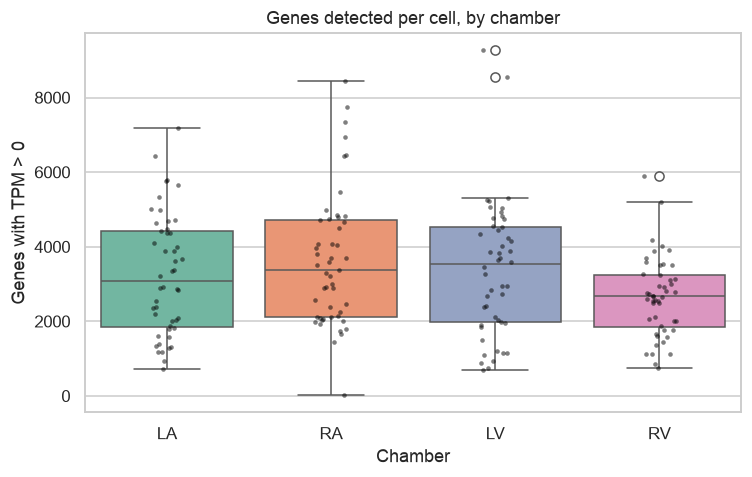

         count    mean     std    min     25%     50%     75%     max
chamber                                                              
LA        48.0  3251.0  1620.0  721.0  1858.0  3072.0  4433.0  7181.0
RA        49.0  3628.0  1792.0   20.0  2114.0  3369.0  4703.0  8440.0
LV        48.0  3388.0  1836.0  693.0  1969.0  3532.0  4533.0  9265.0
RV        48.0  2651.0  1070.0  740.0  1855.0  2667.0  3254.0  5909.0

cells detecting fewer than 500 genes: 1
     chamber  genes_detected
cell                        
RA23      RA              20

after cell QC: 24,153 genes x 192 cells


In [7]:
qc = meta.copy()
qc["tpm_sum"] = expr.sum(axis=0)
qc["genes_detected"] = (expr > 0).sum(axis=0)

# Why the usual QC plot is useless here: TPM is per-column normalised.
print(f"total TPM per cell: min {qc['tpm_sum'].min():,.0f}, "
      f"max {qc['tpm_sum'].max():,.0f}  <- normalised by construction")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=qc, x="chamber", y="genes_detected", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=qc, x="chamber", y="genes_detected", order=CHAMBERS,
              color="black", size=3, alpha=0.5, ax=ax)
ax.set(title="Genes detected per cell, by chamber", xlabel="Chamber",
       ylabel="Genes with TPM > 0")
plt.tight_layout()
plt.show()

print(qc.groupby("chamber", observed=True)["genes_detected"].describe().round(0))

# A cell detecting almost nothing is a failure, not a measurement — so drop it.
# Demonstrating a QC step and then not applying it is worse than skipping it,
# because the reader is left assuming it was handled.
MIN_GENES = 500
low = qc.index[qc["genes_detected"] < MIN_GENES]

print(f"\ncells detecting fewer than {MIN_GENES} genes: {len(low)}")
print(qc.loc[low, ["chamber", "genes_detected"]].to_string())

expr = expr.drop(columns=low)
meta = meta.drop(index=low)
print(f"\nafter cell QC: {expr.shape[0]:,} genes x {expr.shape[1]} cells")

## 4. Filter and transform

### 4.1 Drop genes that are essentially absent

Keep a gene if it exceeds 1 TPM in at least 2 cells.

In [8]:
keep = (expr > 1).sum(axis=1) >= 2

print(f"genes before : {len(keep):,}")
print(f"genes removed: {(~keep).sum():,}")
print(f"genes kept   : {keep.sum():,}")

expr_f = expr.loc[keep]

genes before : 24,153
genes removed: 7,243
genes kept   : 16,910


### 4.2 log1p

Expression data spans several orders of magnitude. `log1p(x)` computes
`log(1 + x)`, which handles zeros gracefully — `log(0)` is undefined, but
`log1p(0)` is 0.

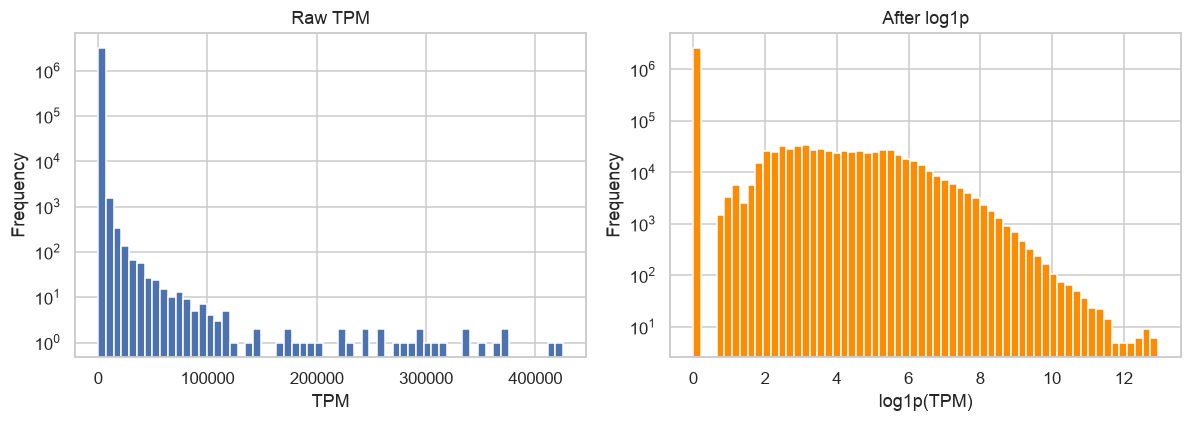

In [9]:
log_tpm = np.log1p(expr_f)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(expr_f.values.flatten(), bins=60)
axes[0].set(title="Raw TPM", xlabel="TPM", ylabel="Frequency", yscale="log")
axes[1].hist(log_tpm.values.flatten(), bins=60, color="darkorange")
axes[1].set(title="After log1p", xlabel="log1p(TPM)", ylabel="Frequency", yscale="log")
plt.tight_layout()
plt.show()

### 4.3 The most highly expressed genes

In [10]:
top10 = log_tpm.mean(axis=1).nlargest(10)
print("top 10 genes by mean expression:")
print(top10.round(3))

top 10 genes by mean expression:
Gene
MYL7      9.349
FTH1      8.697
EEF1A1    8.515
ACTC1     8.513
TPM1      8.474
MYL6      8.353
RPLP1     8.314
GAPDH     8.293
TMSB10    8.237
HSPB1     8.224
dtype: float64


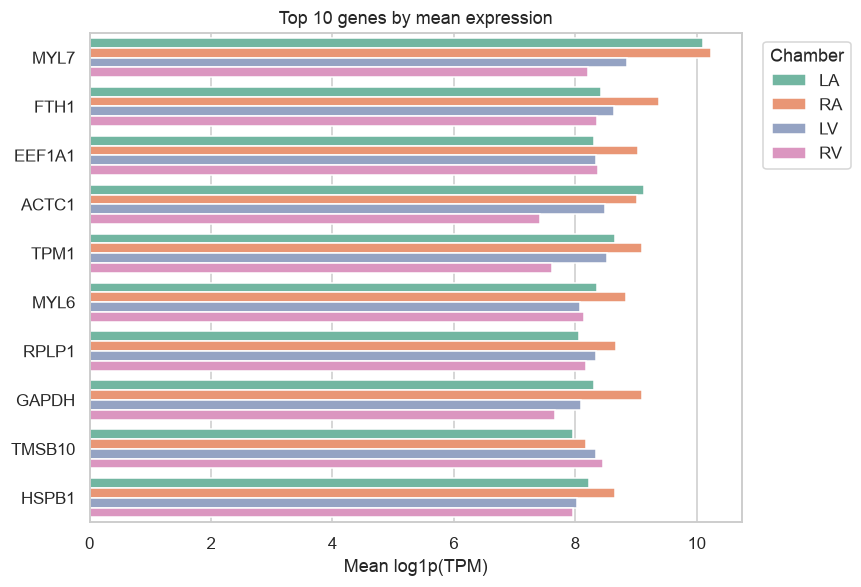

In [11]:
top_long = (
    log_tpm.loc[top10.index]
    .T.join(meta["chamber"])
    .melt(id_vars="chamber", var_name="Gene", value_name="log1p_tpm")
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=top_long, y="Gene", x="log1p_tpm", hue="chamber",
            order=top10.index, hue_order=CHAMBERS, palette=PALETTE,
            errorbar=None, ax=ax)
ax.set(title="Top 10 genes by mean expression", xlabel="Mean log1p(TPM)", ylabel="")
ax.legend(title="Chamber", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Look at what came out. `MYL7`, `ACTC1`, `TPM1` and `MYL6` are sarcomeric — the
contractile machinery of cardiac muscle. `EEF1A1`, `GAPDH`, `TMSB10` and `RPLP1`
are housekeeping and ribosomal genes, which are abundant in any tissue. `FTH1`
stores iron and `HSPB1` is a heat-shock protein enriched in muscle.

That mix is exactly what heart tissue should look like, and it is a good sign
the data is what it claims to be. Checking that the top-expressed genes make
biological sense is a quick, cheap sanity check worth doing on any new dataset.

## 5. Pseudo-bulk: chamber-averaged expression and correlation

From here on we stop working with individual cells and average each gene within
each chamber. That aggregate is a **pseudo-bulk** profile, and it is the honest
unit for any chamber-level claim.

The reason is that the cells are not independent observations. They come from one
embryo, so they share everything about it — its genotype, its developmental
stage, how the tissue was handled. Treating them as independent would let the
number of *cells* stand in for the number of *hearts*, which is not what a
chamber-level question is asking. Averaging to one profile per chamber removes
that temptation.

> **What averaging does not do is remove the zeros.** We average `log1p(TPM)`
> across cells, and roughly 86% of those values are zero, so a gene detected in
> half its cells is pulled toward zero no matter how high it goes when it *is*
> detected. In this dataset the chamber means correlate with per-chamber
> detection rate at Spearman ρ ≈ 0.99 — so read what follows as "how often and
> how strongly a gene is seen", not as expression level alone. Aggregating the
> TPMs first and taking `log1p` afterwards gives a different, more
> expression-weighted answer; neither is wrong, but they are not the same
> question and mixing them is how people get confused.

In [12]:
chamber_means = log_tpm.T.join(meta["chamber"]).groupby("chamber", observed=True).mean().T
chamber_means = chamber_means[CHAMBERS]
# The transpose + groupby drops the index name; restore it so that later
# .reset_index() calls produce a column called "Gene" rather than "index".
chamber_means.index.name = "Gene"
chamber_means.columns.name = None

print(f"gene x chamber matrix: {chamber_means.shape}")
chamber_means.head(3).round(3)

gene x chamber matrix: (16910, 4)


,LA,RA,LV,RV
Gene,,,,
A1BG-AS1,0.526,0.299,0.000,0.000
A2M,1.323,0.000,0.181,0.460
A2M-AS1,0.000,0.133,0.000,0.244


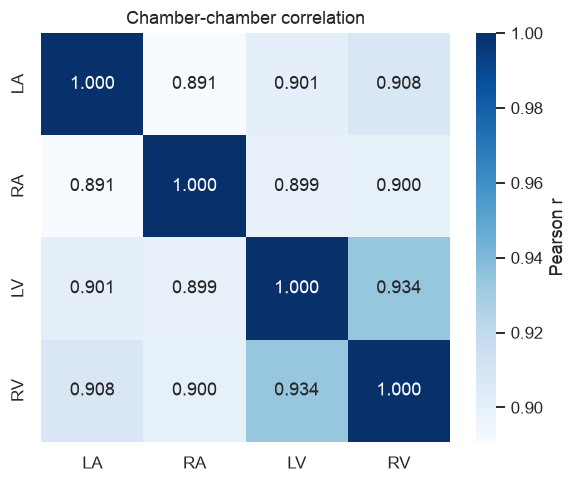

All four chambers are highly correlated — they are all heart muscle.
The interesting signal is in the small differences, not the big similarity.


In [13]:
corr = chamber_means.corr(method="pearson")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr.values.min(), vmax=1.0,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set(title="Chamber-chamber correlation")
plt.tight_layout()
plt.show()

print("All four chambers are highly correlated — they are all heart muscle.")
print("The interesting signal is in the small differences, not the big similarity.")

## 6. Chamber-biased genes

Now the biology. We contrast the two atria against each other, and the two
ventricles against each other, by subtracting the mean expression.

In [14]:
contrasts = {
    "LA vs RA (atria)": ("LA", "RA"),
    "LV vs RV (ventricles)": ("LV", "RV"),
}

biased = {}
for title, (a, b) in contrasts.items():
    d = pd.DataFrame({
        a: chamber_means[a],
        b: chamber_means[b],
        "delta": chamber_means[a] - chamber_means[b],
    })
    d["abs_delta"] = d["delta"].abs()
    biased[title] = d.sort_values("abs_delta", ascending=False)
    print(f"\n--- {title}: 10 most biased genes ---")
    print(biased[title].head(10)[[a, b, "delta"]].round(3))


--- LA vs RA (atria): 10 most biased genes ---
                 LA     RA  delta
Gene                             
ABCC9         6.611  2.980  3.631
L2HGDH        5.497  1.884  3.613
LOC100129434  6.243  2.962  3.281
LOC102724699  6.765  3.519  3.245
INMT          4.758  1.515  3.243
PARP15        5.663  2.473  3.191
MYH7          1.547  4.711 -3.164
ORC4          5.234  2.107  3.126
IFNG          0.061  3.186 -3.124
METTL21A      6.476  3.380  3.096

--- LV vs RV (ventricles): 10 most biased genes ---
          LV     RV  delta
Gene                      
LYZ    6.160  1.749  4.411
MPO    5.230  0.951  4.279
SPP1   1.172  4.695 -3.523
CCL4   0.337  3.078 -2.741
CCL3   0.472  3.086 -2.614
CXCL8  1.218  3.831 -2.613
MT3    3.722  1.156  2.566
IL1B   0.485  3.045 -2.560
PLAC8  2.759  0.365  2.394
RRM2   3.025  0.640  2.385


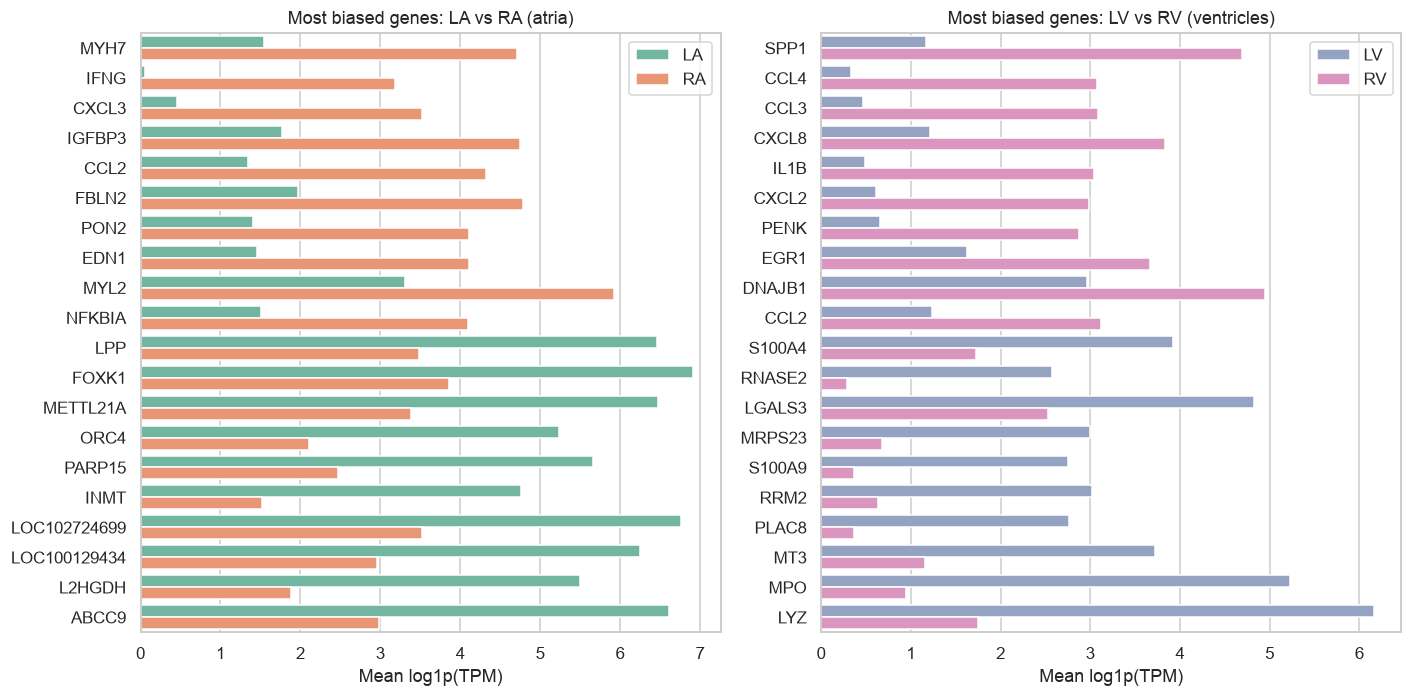

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

for ax, (title, (a, b)) in zip(axes, contrasts.items()):
    d = biased[title]
    top = pd.concat([d.nlargest(10, "delta"), d.nsmallest(10, "delta")])
    plot_df = (
        top[[a, b]].reset_index()
        .melt(id_vars="Gene", var_name="chamber", value_name="mean_log1p")
    )
    order = top.sort_values("delta").index
    sns.barplot(data=plot_df, y="Gene", x="mean_log1p", hue="chamber",
                order=order, palette=PALETTE, ax=ax)
    ax.set(title=f"Most biased genes: {title}", xlabel="Mean log1p(TPM)", ylabel="")
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 7. A single gene across all four chambers

`NOTCH1` is essential for cardiac development and is mutated in several forms of
congenital heart disease — the same disease family as the CHD gene list in S3.

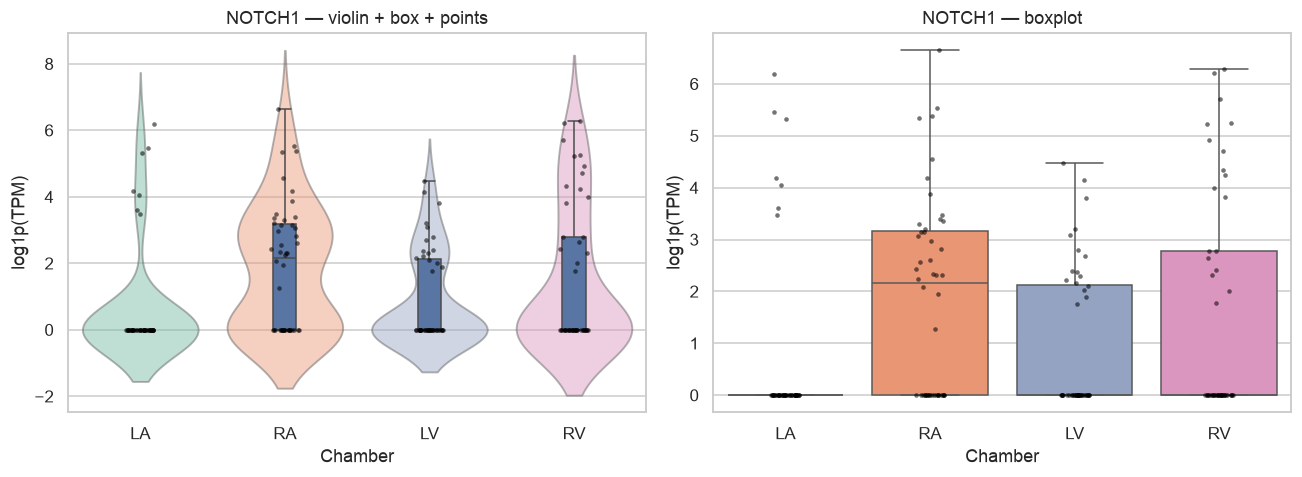

         count   mean    std  min  25%    50%    75%    max
chamber                                                    
LA        48.0  0.672  1.686  0.0  0.0  0.000  0.000  6.184
RA        48.0  1.865  1.907  0.0  0.0  2.165  3.166  6.646
LV        48.0  0.905  1.374  0.0  0.0  0.000  2.118  4.475
RV        48.0  1.488  2.133  0.0  0.0  0.000  2.782  6.291


In [16]:
GENE = "NOTCH1"
assert GENE in log_tpm.index, f"{GENE} not found"

gene_df = meta.copy()
gene_df["expression"] = log_tpm.loc[GENE]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.violinplot(data=gene_df, x="chamber", y="expression", hue="chamber",
               order=CHAMBERS, palette=PALETTE, legend=False,
               inner=None, alpha=0.45, ax=axes[0])
sns.boxplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
            width=0.16, showfliers=False, boxprops={"zorder": 2}, ax=axes[0])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[0])
axes[0].set(title=f"{GENE} — violin + box + points", xlabel="Chamber",
            ylabel="log1p(TPM)")

sns.boxplot(data=gene_df, x="chamber", y="expression", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False,
            showfliers=False, ax=axes[1])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[1])
axes[1].set(title=f"{GENE} — boxplot", xlabel="Chamber", ylabel="log1p(TPM)")

plt.tight_layout()
plt.show()

print(gene_df.groupby("chamber", observed=True)["expression"].describe().round(3))

## 8. Pairwise statistical comparison

The question has to be stated carefully here, because the answer depends on it.

We are comparing **cells within one embryo**: do the RA cells and the LV cells of
*this heart* differ in NOTCH1 expression? That is a legitimate question, and the
Mann-Whitney below answers it correctly — read the `n1` and `n2` columns in the
table for the exact counts, which are the numbers of cells left after the QC step
in section 3.

What it does not answer is whether the right atrium differs from the left
ventricle *in humans*. For that the unit of replication is the embryo, and we have
one. No test on cells from a single heart can widen the claim, however small the
p-value gets.

> **The replication ladder: cells → embryo → population.** A test is valid at the
> level whose units it actually resamples. Every rung up the ladder needs new
> units, not more measurements of the units you already have. Treating cells as
> biological replicates — *pseudoreplication* — is one of the most common errors
> in genomics, and it makes p-values look far smaller than the evidence supports.
> When you read `n1` below, read it as a count of *cells*, not of hearts.

Six pairwise comparisons between four chambers still means six chances of a false
positive, so we correct with Benjamini-Hochberg. That part is independent of which
rung of the ladder you are standing on.

> R does this in one call: `pairwise.wilcox.test(..., p.adjust.method = "BH")`.
> Python needs two steps — the tests, then the correction — which makes the
> multiple-testing step visible instead of hidden in a default argument.

In [17]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(CHAMBERS, 2):
    x = gene_df.loc[gene_df["chamber"] == a, "expression"]
    y = gene_df.loc[gene_df["chamber"] == b, "expression"]
    u = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({
        "group1": a, "group2": b,
        "n1": len(x), "n2": len(y),
        "median1": x.median(), "median2": y.median(),
        "U": u.statistic, "p_raw": u.pvalue,
    })

pw = pd.DataFrame(rows)
pw["p_adj"] = multipletests(pw["p_raw"], method="fdr_bh")[1]
pw["significant"] = pw["p_adj"] < 0.05
pw = pw.sort_values("p_adj").reset_index(drop=True)

print(f"pairwise comparisons of {GENE} expression (BH-corrected):")
print(pw.round(4).to_string(index=False))

pairwise comparisons of NOTCH1 expression (BH-corrected):
group1 group2  n1  n2  median1  median2      U  p_raw  p_adj  significant
    LA     RA  48  48   0.0000   2.1651  734.5 0.0004 0.0021         True
    RA     LV  48  48   2.1651   0.0000 1490.0 0.0067 0.0201         True
    LA     RV  48  48   0.0000   0.0000  903.0 0.0183 0.0366         True
    LA     LV  48  48   0.0000   0.0000  983.0 0.0991 0.1486        False
    RA     RV  48  48   2.1651   0.0000 1310.0 0.2107 0.2528        False
    LV     RV  48  48   0.0000   0.0000 1030.0 0.2976 0.2976        False


## 9. Export a report

Top 50 genes per chamber, one worksheet per chamber — the equivalent of the R
lesson's `openxlsx` workbook loop.

In [18]:
TOP_N = 50
report_file = OUT / "TopGenes_perChamber.xlsx"

with pd.ExcelWriter(report_file, engine="openpyxl") as writer:
    for chamber in CHAMBERS:
        top = (
            chamber_means[chamber]
            .nlargest(TOP_N)
            .rename("mean_log1p_tpm")
            .reset_index()
        )
        top.insert(0, "rank", range(1, len(top) + 1))
        top.to_excel(writer, sheet_name=chamber, index=False)

print(f"wrote {report_file} ({report_file.stat().st_size:,} bytes)")

check = pd.read_excel(report_file, sheet_name=None)
print(f"sheets written: {list(check.keys())}")
print(f"rows per sheet: {[len(v) for v in check.values()]}")
print("\nLA sheet, first rows:")
print(check["LA"].head().round(3))

wrote ../results/py/TopGenes_perChamber.xlsx (12,402 bytes)
sheets written: ['LA', 'RA', 'LV', 'RV']
rows per sheet: [50, 50, 50, 50]

LA sheet, first rows:
   rank   Gene  mean_log1p_tpm
0     1   MYL7          10.105
1     2  ACTC1           9.130
2     3   NPPA           8.841
3     4   TPM1           8.657
4     5   FTH1           8.417


> **On output paths.** We write to `results/py/`, a fixed location relative to
> this notebook. The R version of this lesson used `getwd()`, which meant the
> file landed wherever the notebook happened to be run from — and in practice
> ended up written to two different folders. Always anchor your output paths.

## 10. Where to go next: functional enrichment

You now have a ranked gene list per chamber. The obvious next question is what
those genes *do*.

Paste one of the exported sheets into **Enrichr** (<https://maayanlab.cloud/Enrichr/>)
to test it against GO terms, pathways and disease annotations.

To do it in Python instead, `gseapy` wraps the same service:

```python
# pip install gseapy
import gseapy as gp
enr = gp.enrichr(
    gene_list=chamber_means["LA"].nlargest(200).index.tolist(),
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
    organism="human",
)
enr.results.head(10)
```

We leave this as an exercise because it needs internet access at run time.

In [19]:
# Optional: gene-set enrichment. This is the "leave it as an exercise" section
# above, made runnable. Two things it has to get right:
#
#   * install into THIS kernel (sys.executable), not into whatever `pip` happens
#     to be first on PATH - that is a different interpreter more often than not;
#   * not break Run All when there is no internet, since gseapy is not part of
#     the pinned course environment (it has no current Windows conda build).
import subprocess
import sys

try:
    import gseapy as gp
except ModuleNotFoundError:
    print("installing gseapy into", sys.executable)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gseapy"], check=False)
    try:
        import gseapy as gp
    except ModuleNotFoundError:
        gp = None
        print("gseapy is unavailable - skipping the enrichment step.")

if gp is not None:
    try:
        enr = gp.enrichr(
            gene_list=chamber_means["LA"].nlargest(200).index.tolist(),
            gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
            organism="human",
        )
        display(enr.results.head(10))
    except Exception as exc:                      # network, or Enrichr being down
        print(f"enrichment skipped: {type(exc).__name__}: {exc}")

# Worth noticing in the result: ranking by absolute expression puts ribosomal
# genes at the top, so the enrichment comes back dominated by translation terms.
# Exercise 5 removes those genes - ranking by a contrast instead of by level is
# what makes an enrichment interpretable.

installing gseapy into /Users/enrique/miniconda3/envs/zebraq-run/bin/python


gseapy is unavailable - skipping the enrichment step.


  error: subprocess-exited-with-error
  
  × Building wheel for gseapy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [44 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/algorithm.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/ssgsea.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/plot.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/enrichr.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/msigdb.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/__init__.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/parser.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/scipalette.py -> build/lib.macosx-11.0-x86_64-cpython-311/gseapy
      copying gseapy/utils.py -> build/lib.mac

## 11. Exercises

1. How many genes are expressed above 1 TPM in *every* cell? Given how sparse
   this matrix is, what does the answer actually measure?
2. Redo the chamber correlation with Spearman instead of Pearson. Does the
   picture change? What would it mean if it did?
3. Compare atria (LA + RA) against ventricles (LV + RV) instead of the
   within-pair contrasts. Which genes separate them most strongly?
4. Pick another CHD gene — `GATA4`, `TBX5` or `NKX2-5` — and repeat sections 7
   and 8 for it.
5. Several of the top-expressed genes are ribosomal (`RPLP1`, and `RPL41`,
   `RPS27`, `RPL31` just below the top 10). They are abundant in every tissue and
   tell you nothing about the heart. Remove genes whose name starts with `RPL` or
   `RPS` and redo section 4.3 — does the remaining list look more cardiac?

   Then check how many genes in this dataset start with `MT-` (the prefix for
   mitochondrially encoded transcripts). The answer may surprise you, and it is a
   reminder to verify that a filter matches something before trusting it. Careful:
   `MT` without the dash matches the metallothionein family, which is unrelated.

### Exercise 1
How many genes are expressed above 1 TPM in *every* cell?

In [20]:
# "In every cell" means all of them, so compare against the number of columns
# rather than a hard-coded number - .all(axis=1) says it directly and cannot
# go stale if the matrix is ever subset.
genes_in_all = (expr > 1).all(axis=1).sum()

print(f"cells in the matrix: {expr.shape[1]}")
print(f"Genes expressed above 1 TPM in every cell: {genes_in_all}")

# Two things worth noticing.
#
# The number is small because this is single-cell data: most of the matrix is
# zero and the median cell detects only a few thousand genes, so this measures
# dropout as much as it measures ubiquitous expression.
#
# And it depends on the QC in section 3. Before that step the matrix still held
# RA23, a failed cell detecting 20 genes, and "expressed in every cell" then had
# to clear that cell too - which dropped the count from 34 to 5. One dead column
# moved the answer almost sevenfold. That is what cell QC is for.

cells in the matrix: 192
Genes expressed above 1 TPM in every cell: 34


### Exercise 2
changing pearson to spearman methodd

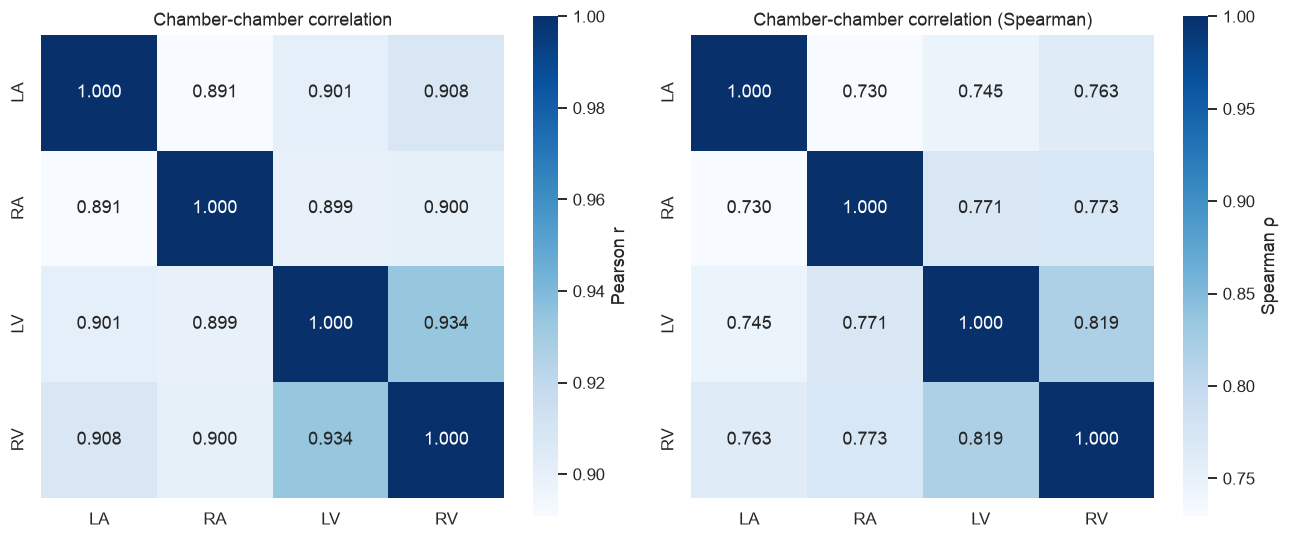

In [21]:
#calculating both cirrelations
corr_pearson = chamber_means.corr(method="pearson")
corr_spearman = chamber_means.corr(method="spearman")

#creating figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#creating pearson heatmap
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr.values.min(), vmax=1.0,
            cbar_kws={"label": "Pearson r"}, ax=ax1)
ax1.set(title="Chamber-chamber correlation")

#creating spearman heatmap
sns.heatmap(corr_spearman, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr_spearman.values.min(), vmax=1.0,
            cbar_kws={"label": "Spearman ρ"}, ax=ax2)
ax2.set(title="Chamber-chamber correlation (Spearman)")

plt.tight_layout()
plt.show()

The expression of gene is a continuous variable instead of being categorical. Spearman method is to correlate categorical variables and the slight changes in value would mean that it does not measure the correlation between a contnuos variable correctly. hence, pearson is the ideal choice for such case.

#### Exercise 3
Find genes that are higher in atria (LA+RA) vs ventricles (LV+RV).


In [22]:
# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by difference (most biased)
top_genes = delta.nlargest(10).index  #positive delta means higher in atria, negative means higher in ventricles

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYH6            5.259
NPPA            4.011
PAM             3.748
LOC101928304    3.527
NPPB            3.414
LOC101929733    3.229
TAGLN           2.935
CAV1            2.786
TBX5            2.584
DKK3            2.568
dtype: float64


In [23]:
# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by difference (most biased)
top_genes = delta.nsmallest(10).index  #positive delta means higher in atria, negative means higher in ventricles

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYL2   -3.161
HBB    -2.859
HBG1   -2.671
LYZ    -2.666
HBM    -2.627
MYH7   -2.612
DLK1   -2.497
AHSP   -2.496
HBA1   -2.309
MPO    -2.303
dtype: float64


In [24]:
#we can also compared the genes that aree highest in both atria and ventrices using absoute value of the difference which will 
# compare the genes that are highest in both atria and ventricles regardless of which chamber they are higher in.

# Group chambers: Atria = LA + RA, Ventricles = LV + RV
atria_mean = chamber_means[["LA", "RA"]].mean(axis=1)
ventricles_mean = chamber_means[["LV", "RV"]].mean(axis=1)

# Difference: Atria - Ventricles
delta = atria_mean - ventricles_mean

# Sort by absolute difference (most biased)
top_genes = delta.abs().nlargest(10).index

print("Top 10 genes separating atria from ventricles:")
print(delta.loc[top_genes].round(3))

Top 10 genes separating atria from ventricles:
Gene
MYH6            5.259
NPPA            4.011
PAM             3.748
LOC101928304    3.527
NPPB            3.414
LOC101929733    3.229
MYL2           -3.161
TAGLN           2.935
HBB            -2.859
CAV1            2.786
dtype: float64


### Exercise 4
Repeat the single-gene analysis (plot + stats) for a different congenital heart disease gene.

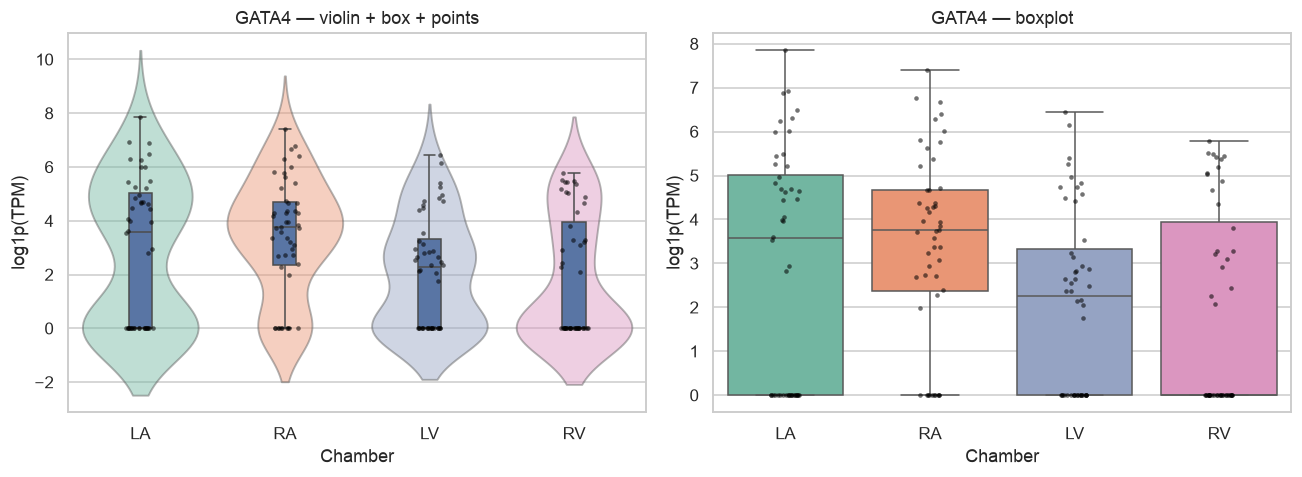

         count   mean    std  min    25%    50%    75%    max
chamber                                                      
LA        48.0  2.841  2.697  0.0  0.000  3.572  5.019  7.849
RA        48.0  3.426  2.155  0.0  2.361  3.752  4.681  7.399
LV        48.0  2.096  2.059  0.0  0.000  2.268  3.316  6.437
RV        48.0  1.845  2.262  0.0  0.000  0.000  3.946  5.776


In [25]:
GENE = "GATA4"
assert GENE in log_tpm.index, f"{GENE} not found"

# Create gene dataframe
gene_df = meta.copy()
gene_df["expression"] = log_tpm.loc[GENE]

# Plot: Violin + box + strip
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.violinplot(data=gene_df, x="chamber", y="expression", hue="chamber",
               order=CHAMBERS, palette=PALETTE, legend=False, inner=None, alpha=0.45, ax=axes[0])
sns.boxplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, width=0.16, showfliers=False, boxprops={"zorder": 2}, ax=axes[0])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, color="black", size=3, alpha=0.55, ax=axes[0])
axes[0].set(title=f"{GENE} — violin + box + points", xlabel="Chamber", ylabel="log1p(TPM)")

# Clean boxplot
sns.boxplot(data=gene_df, x="chamber", y="expression", hue="chamber", order=CHAMBERS, palette=PALETTE, legend=False, showfliers=False, ax=axes[1])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS, color="black", size=3, alpha=0.55, ax=axes[1])
axes[1].set(title=f"{GENE} — boxplot", xlabel="Chamber", ylabel="log1p(TPM)")

plt.tight_layout()
plt.show()

# Summary stats
print(gene_df.groupby("chamber", observed=True)["expression"].describe().round(3))

In [26]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(CHAMBERS, 2):
    x = gene_df.loc[gene_df["chamber"] == a, "expression"]
    y = gene_df.loc[gene_df["chamber"] == b, "expression"]
    u = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({
        "group1": a, "group2": b,
        "n1": len(x), "n2": len(y),
        "median1": x.median(), "median2": y.median(),
        "U": u.statistic, "p_raw": u.pvalue,
    })

pw = pd.DataFrame(rows)
pw["p_adj"] = multipletests(pw["p_raw"], method="fdr_bh")[1]
pw["significant"] = pw["p_adj"] < 0.05
pw = pw.sort_values("p_adj").reset_index(drop=True)

print(f"pairwise comparisons of {GENE} expression (BH-corrected):")
print(pw.round(4).to_string(index=False))

pairwise comparisons of GATA4 expression (BH-corrected):
group1 group2  n1  n2  median1  median2      U  p_raw  p_adj  significant
    RA     LV  48  48   3.7518   2.2676 1548.0 0.0032 0.0097         True
    RA     RV  48  48   3.7518   0.0000 1570.0 0.0016 0.0097         True
    LA     RV  48  48   3.5724   0.0000 1382.5 0.0716 0.1432        False
    LA     LV  48  48   3.5724   2.2676 1340.0 0.1525 0.2287        False
    LA     RA  48  48   3.5724   3.7518 1059.0 0.4905 0.5771        False
    LV     RV  48  48   2.2676   0.0000 1224.0 0.5771 0.5771        False


### Exercise 5
Remove ribosomal genes and re-do the top genes.
Check for mitochondrial (MT-) genes


In [27]:
top10 = log_tpm.mean(axis=1).nlargest(10)
print("top 10 genes by mean expression:")
print(top10.round(3))

top 10 genes by mean expression:
Gene
MYL7      9.349
FTH1      8.697
EEF1A1    8.515
ACTC1     8.513
TPM1      8.474
MYL6      8.353
RPLP1     8.314
GAPDH     8.293
TMSB10    8.237
HSPB1     8.224
dtype: float64


In [28]:
#Step 1 - removing ribosomal genes
# Section 4.3 ranks on log_tpm, so the comparison has to use log_tpm too.
# Ranking the raw TPM instead would be dominated by a handful of extreme cells
# and the two lists would not be comparable.
ribosomal = log_tpm.index.str.startswith(("RPL", "RPS"))
print(f"Ribosomal genes removed: {ribosomal.sum()}")

log_tpm_filtered = log_tpm[~ribosomal]

# Find top 10 genes by mean expression, same as section 4.3
top10_filtered = log_tpm_filtered.mean(axis=1).nlargest(10)
print("\nTop 10 genes (after removing ribosomal):")
print(top10_filtered.round(3))

# RPLP1 drops out and TNNC1 - cardiac troponin - takes its place, so the list
# does become slightly more cardiac.

Ribosomal genes removed: 114

Top 10 genes (after removing ribosomal):
Gene
MYL7      9.349
FTH1      8.697
EEF1A1    8.515
ACTC1     8.513
TPM1      8.474
MYL6      8.353
GAPDH     8.293
TMSB10    8.237
HSPB1     8.224
TNNC1     8.129
dtype: float64


In [29]:
# Step 2 - counting mitochondrial genes
# Count genes starting with MT- (mitochondrial)
mt_genes = expr_f.index.str.startswith("MT-")
print(f"Genes starting with MT-: {mt_genes.sum()}")

# Show them
print("\nMT- genes:")
print(expr_f.index[mt_genes].tolist())

Genes starting with MT-: 0

MT- genes:
[]


## 12. Session information

In [30]:
import sys

from IPython.display import display

try:
    import session_info
except ModuleNotFoundError:
    # Not an error in your code: this kernel simply does not have session-info.
    # It ships with the course environment (setup/python/environment.yml).
    # The interpreter path below is the fastest way to see which Python the
    # notebook is actually using, which is usually the real problem.
    print("session-info is not installed in this kernel.")
    print("kernel:", sys.executable)
    print("See setup/python/README.md to select the ZebraQ environment.")
else:
    # display() rather than a bare call: inside try/except the returned HTML is
    # no longer the cell's last expression, so Jupyter would not render it.
    display(session_info.show())